In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
def load_data(folder="Decision Tree-Dataset"):
    """
    Loads the dataset and extracts features using CountVectorizer.
    Splits into 70% train, 15% validation, and 15% test.
    """
    with open(os.path.join(folder, "real.txt"), "r", encoding="utf-8") as f:
        real_headlines = f.readlines()
    with open(os.path.join(folder, "fake.txt"), "r", encoding="utf-8") as f:
        fake_headlines = f.readlines()

    #Using labels to distinguish headlines; 1 for real, 0 for fake
    headlines = real_headlines + fake_headlines
    labels = np.array([1] * len(real_headlines) + [0] * len(fake_headlines))

    #Convert text to numerical features using the CountVectorizer class
    vectorizer = CountVectorizer()
    X = vectorizer.fit_transform(headlines)

    #Splitting the dataset into train, validation, and test samples
    X_train, X_temp, y_train, y_temp = train_test_split(X, labels, test_size=0.3, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

    return X_train, X_val, X_test, y_train, y_val, y_test, vectorizer

X_train, X_val, X_test, y_train, y_val, y_test, vectorizer = load_data()


Max Depth: 2, Validation Accuracy: 0.6857
Max Depth: 4, Validation Accuracy: 0.6796
Max Depth: 6, Validation Accuracy: 0.6816
Max Depth: 8, Validation Accuracy: 0.6857
Max Depth: 10, Validation Accuracy: 0.6980


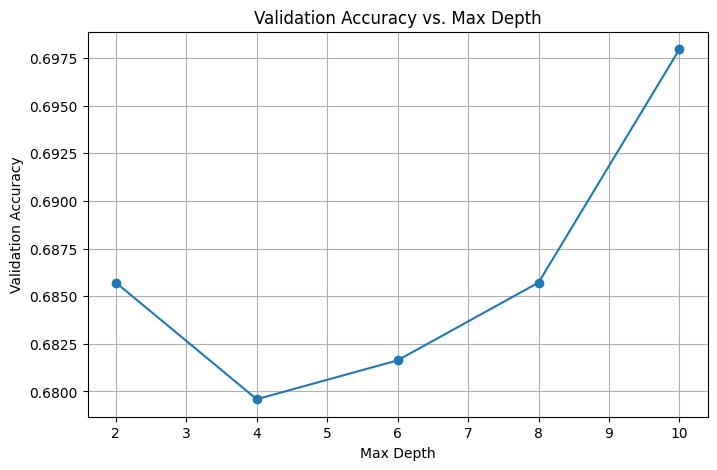

Best Depth: 10


In [ ]:
def select_model(X_train, X_val, y_train, y_val):
    """
    Trains and evaluates the Decision Tree models with 5 different max depth values and plots the
    validation accuracy against the max depth values to identify the best depth. 
    """
    max_depth_values = [2, 4, 6, 8, 10]
    accuracies = []
    # for each depth value, train the decision tree model
    for depth in max_depth_values:
        
        model = DecisionTreeClassifier(max_depth=depth, criterion="entropy", random_state=42)
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)
        
        # calculate the accuracy
        correct_predictions = np.sum(y_pred == y_val)
        accuracy = correct_predictions / len(y_val)
        
        accuracies.append(accuracy)
        print(f"Max Depth: {depth}, Validation Accuracy: {accuracy:.4f}")

    # plot validation accuracy vs max_depth
    plt.figure(figsize=(8, 5))
    plt.plot(max_depth_values, accuracies, marker='o', linestyle='-')
    plt.xlabel("Max Depth")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy vs. Max Depth")
    plt.grid()
    plot_folder = "plots"
    plt.savefig(os.path.join(plot_folder, "ValidationAccvsMaxDepth.png"))
    plt.show()

    best_depth = max_depth_values[np.argmax(accuracies)]
    return best_depth

best_depth = select_model(X_train, X_val, y_train, y_val)
print("Best Depth:", best_depth)

In [ ]:
def evaluate_test_set(X_train, X_test, y_train, y_test, best_depth):
    """
    Train the decision tree classifier using the most accurate max depth from the validation sample
    """
    model = DecisionTreeClassifier(max_depth=best_depth, criterion="entropy", random_state=42)
    model.fit(X_train, y_train)

    # predict on the test set
    y_pred = model.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_pred)
    print(f"Test Accuracy with max_depth={best_depth}: {test_accuracy:.4f}")
    return model

best_model = evaluate_test_set(X_train, X_test, y_train, y_test, best_depth)


Test Accuracy with max_depth=10: 0.7184


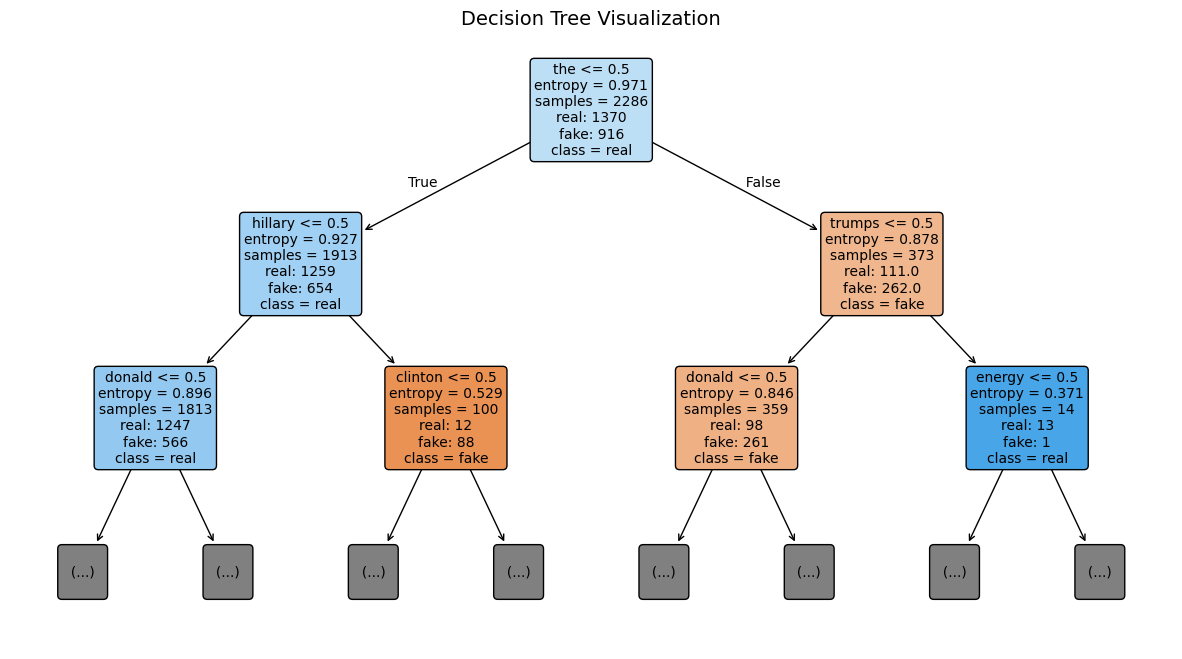

In [ ]:
def visualize_tree(model, vectorizer, max_depth=2):
    """
    Visualize the trained decision tree classifier and save the figure to the plots folder
    """
    feature_names = vectorizer.get_feature_names_out()
    class_names = ["fake", "real"]

    plt.figure(figsize=(15, 8))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=10,
        impurity=True,  
        proportion=False, 
        label="all",
        max_depth=max_depth
    )
    ax = plt.gca()  
    for i, text in enumerate(ax.texts):
        if "value =" in text.get_text():  
            value_str = text.get_text().split("value =")[1].split("\n")[0]
            values = eval(value_str.strip())  
            if len(values) == 2:  
                fake, real = values
                new_label = f"real: {real}\nfake: {fake}"  
                text.set_text(text.get_text().replace(f"value = {values}", new_label))
    
    plt.title("Decision Tree Visualization", fontsize=14)
    plot_folder = "plots"
    plt.savefig(os.path.join(plot_folder, "DecisionTreeVisual.png"))
    plt.show()

    
visualize_tree(best_model, vectorizer)